Day_02_Database_SQL_Visualization

In [143]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Print import confirmation and versions
print('All libraries imported successfully')
print(f"sqlite3 version : {sqlite3.version}")
print(f'Pandas version: {pd.__version__}')
print(f'Matplotlib version: {plt.matplotlib.__version__}')

All libraries imported successfully
sqlite3 version : 2.6.0
Pandas version: 2.2.2
Matplotlib version: 3.10.0


In [144]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [145]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded : {df.shape[0]} student, {df.shape[1]} column, ")
print (f"columns : {df.columns.to_list()}")
print(f"first five row ")
display(df.head(5))

Dataset loaded : 30 student, 13 column, 
columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
first five row 


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [146]:
# Connect to 'collage.db'
conn = sqlite3.connect('collage.db')

# Create cursor
cursor = conn.cursor()

# Save df to 'student_performance' table
df.to_sql('student_performance',
          conn, if_exists='replace',
          index=False)

# Commit changes
conn.commit()

# Count rows in 'student_performance'
cursor.execute("SELECT COUNT(*) FROM student_performance")

# Get count
count = cursor.fetchone()[0]

# Print confirmation
print(f"Successfully loaded {count} students into the 'student_performance' table in 'collage.db'.")
print(f"Database 'college.db' created successfully")
print(f"Table 'students' has {count} rows")

# Close connection
conn.close()

Successfully loaded 30 students into the 'student_performance' table in 'collage.db'.
Database 'college.db' created successfully
Table 'students' has 30 rows


In [147]:
# Get table schema
conn = sqlite3.connect('collage.db') # Connect
cursor = conn.cursor() # Cursor
cursor.execute("PRAGMA table_info(student_performance)")

# Fetch column info
column_info = cursor.fetchall()

# Print table structure
print("\nTable structure of Students:")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("- "*30)

# Print column details
for col in column_info:
  print(f'{col[1]:<25} {col[2]:<12}')

# Close connection
conn.close()


Table structure of Students:
Column Name               Data Type   
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


```sql
SELECT column1, column2 -- Specifies the columns to retrieve
FROM table_name -- Indicates the table from which to retrieve data
WHERE condition -- Filters the rows based on a specified condition
GROUP BY column1 -- Groups rows that have the same values in specified columns into summary rows
HAVING group_condition -- Filters groups based on a specified condition
ORDER BY column DESC -- Sorts the result set by one or more columns
LIMIT 10; -- Limits the number of rows returned by the query
```

In [148]:
def run_query(sql, description=""):
  """Runs a SQL Query and returns the result as a pandas DataFrame.

  Parameters:
  -------------
  sql : str
      The SQL query string to execute.
  description : str
      A label to print above the result.

  Returns :
      pd.DataFrame: Pandas DataFrame containing the query result.
  """
  if description:
    print(f"\n{'='*55}") # Print a separator line
    print(description)
    print(f"{'='*55}") # Print another separator line

  # Establish a new connection for each query
  conn = sqlite3.connect('collage.db')
  try:
    # Execute the SQL query and load results into a DataFrame
    result = pd.read_sql_query(sql, conn)

    # Print the DataFrame content without the index
    print(result.to_string(index=False))

    return result
  finally:
    # Ensure the connection is closed even if an error occurs
    conn.close()

In [149]:
# Query for first 10 students
sql_query1 = """SELECT name,
 student_id,
 department,
  math_score,
   attendance_percentage
    FROM student_performance LIMIT 10;"""
run_query(sql_query1, description="First 10 students with specific details:")


First 10 students with specific details:
        name  student_id       department  math_score  attendance_percentage
Aarav Sharma        1001 Computer Science          85                     92
 Priya Patel        1002 Computer Science          76                     87
 Rohit Verma        1003      Electronics          65                     78
 Sneha Reddy        1004       Mechanical          70                     95
  Arjun Nair        1005 Computer Science          92                     90
 Meera Joshi        1006      Electronics          58                     72
 Kiran Kumar        1007            Civil          73                     85
 Divya Singh        1008 Computer Science          88                     96
Rahul Mishra        1009       Mechanical          62                     68
  Ananya Das        1010 Computer Science          95                     98


,name,student_id,department,math_score,attendance_percentage
0,Aarav Sharma,1001,Computer Science,85,92
1,Priya Patel,1002,Computer Science,76,87
2,Rohit Verma,1003,Electronics,65,78
3,Sneha Reddy,1004,Mechanical,70,95
4,Arjun Nair,1005,Computer Science,92,90
5,Meera Joshi,1006,Electronics,58,72
6,Kiran Kumar,1007,Civil,73,85
7,Divya Singh,1008,Computer Science,88,96
8,Rahul Mishra,1009,Mechanical,62,68
9,Ananya Das,1010,Computer Science,95,98


In [150]:
sql_query2 = """SELECT name, department, math_score
FROM student_performance
ORDER BY math_score DESC
LIMIT 5;"""
run_query(sql_query2, description="Top 5 students by math score:")


Top 5 students by math score:
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [151]:
# Query for CS students by programming score
sql_query3 = """
SELECT name, math_score, science_score, programming_score, attendance_percentage
FROM student_performance
WHERE department = 'Computer Science'
ORDER BY programming_score DESC;
"""
run_query(sql_query3, description="Students from Computer Science ordered by Programming Score:")


Students from Computer Science ordered by Programming Score:
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor

,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87


In [152]:
# Query for high attendance, non-Civil students
sql_query4="""
SELECT name, department
FROM student_performance
WHERE attendance_percentage > 90
AND department != 'Civil'
ORDER BY attendance_percentage DESC;
"""
run_query(sql_query4, description="Students with >90% attendance and not from Civil department, ordered by attendance:")


Students with >90% attendance and not from Civil department, ordered by attendance:
          name       department
    Ananya Das Computer Science
   Tanvi Mehta Computer Science
   Divya Singh Computer Science
   Sneha Reddy       Mechanical
Akanksha Yadav Computer Science
Swati Kulkarni Computer Science
  Ritu Agarwal      Electronics
  Aarav Sharma Computer Science
 Kavya Nambiar       Mechanical
     Amit Bose Computer Science


,name,department
0,Ananya Das,Computer Science
1,Tanvi Mehta,Computer Science
2,Divya Singh,Computer Science
3,Sneha Reddy,Mechanical
4,Akanksha Yadav,Computer Science
5,Swati Kulkarni,Computer Science
6,Ritu Agarwal,Electronics
7,Aarav Sharma,Computer Science
8,Kavya Nambiar,Mechanical
9,Amit Bose,Computer Science


In [153]:
query5 = """
  SELECT
    department,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math_score,
    ROUND(AVG(science_score), 2) AS avg_science_score,
    ROUND(AVG(english_score), 2) AS avg_english_score,
    ROUND(AVG(programming_score), 2) AS avg_programming_score,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage
  FROM student_performance
  GROUP BY department
  ORDER BY department
"""

result5 = run_query(query5, "GROUP BY with Aggregate Function")
display(result5)


GROUP BY with Aggregate Function
      department  num_students  avg_math_score  avg_science_score  avg_english_score  avg_programming_score  avg_attendance_percentage
           Civil             5           63.40              66.60              65.20                  40.60                      74.60
Computer Science            13           85.62              84.46              80.85                  89.23                      90.69
     Electronics             6           71.00              74.17              70.83                  61.50                      80.33
      Mechanical             6           71.00              76.50              70.50                  49.33                      83.50


,department,num_students,avg_math_score,avg_science_score,avg_english_score,avg_programming_score,avg_attendance_percentage
0,Civil,5,63.40,66.60,65.20,40.60,74.60
1,Computer Science,13,85.62,84.46,80.85,89.23,90.69
2,Electronics,6,71.00,74.17,70.83,61.50,80.33
3,Mechanical,6,71.00,76.50,70.50,49.33,83.50


In [154]:
sql_query6 = """
  SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math,
    COUNT(*) AS students
  FROM student_performance
  GROUP BY department
  HAVING AVG(math_score) > 70
  ORDER BY avg_math DESC
"""

result6 = run_query(sql_query6, "HAVING (filter on groups)")
display(result6)


HAVING (filter on groups)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


,department,avg_math,students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


In [155]:
sql_query7="""
SELECT
  gender,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score), 3) AS avg_math,
  ROUND(AVG(programming_score), 3) AS avg_programming,
  ROUND(AVG(attendance_percentage), 3) AS avg_attendance
FROM student_performance
GROUP BY gender
"""

result7 = run_query(sql_query7, "Aggregated Scores by Gender")
display(result7)


Aggregated Scores by Gender
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15    78.467             70.2          88.533
  Male            15    73.667             65.0          80.467


,gender,num_students,avg_math,avg_programming,avg_attendance
0,Female,15,78.467,70.2,88.533
1,Male,15,73.667,65.0,80.467


In [156]:
query8 = """
  SELECT
    student_id,
    name,
    department,
    math_score + science_score + english_score + programming_score AS total_score
  FROM student_performance
  ORDER BY total_score DESC
  LIMIT 10
"""
result8 = run_query(query8, "Top 10 Students by Total Score")
display(result8)


Top 10 Students by Total Score
 student_id           name       department  total_score
       1010     Ananya Das Computer Science          371
       1022    Tanvi Mehta Computer Science          367
       1030 Akanksha Yadav Computer Science          365
       1005     Arjun Nair Computer Science          356
       1008    Divya Singh Computer Science          356
       1018 Swati Kulkarni Computer Science          354
       1025      Amit Bose Computer Science          336
       1013     Suresh Rao Computer Science          334
       1020   Nisha Kapoor Computer Science          327
       1001   Aarav Sharma Computer Science          326


,student_id,name,department,total_score
0,1010,Ananya Das,Computer Science,371
1,1022,Tanvi Mehta,Computer Science,367
2,1030,Akanksha Yadav,Computer Science,365
3,1005,Arjun Nair,Computer Science,356
4,1008,Divya Singh,Computer Science,356
5,1018,Swati Kulkarni,Computer Science,354
6,1025,Amit Bose,Computer Science,336
7,1013,Suresh Rao,Computer Science,334
8,1020,Nisha Kapoor,Computer Science,327
9,1001,Aarav Sharma,Computer Science,326


In [157]:
# Create department table
department_data = {
    'department_id': [1, 2, 3, 4, 5],
    'department_name': ['Computer Science', 'Electronics', 'Mechanical', 'Civil', 'Electrical'],
    'establishment_year': [1985, 1990, 1988, 1992, 1987],
    'total_intake': [120, 90, 80, 70, 60]
}
df_departments = pd.DataFrame(department_data)

# Connect and create table
conn = sqlite3.connect('collage.db')
df_departments.to_sql('department', conn, if_exists='replace', index=False)
conn.commit()

# Verify table creation
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM department")
count = cursor.fetchone()[0]
print(f"Successfully loaded {count} departments into the 'department' table.")

# Demonstrate JOIN
join_query = """
SELECT
  s.name,
  s.department,
  d.establishment_year,
  d.total_intake,
  s.math_score
FROM student_performance s
JOIN department d ON s.department = d.department_name
ORDER BY s.name
LIMIT 10;
"""

result_join = run_query(join_query, "Student performance with Department details (JOIN demo)")
display(result_join)

conn.close()

Successfully loaded 5 departments into the 'department' table.

Student performance with Department details (JOIN demo)
          name       department  establishment_year  total_intake  math_score
  Aarav Sharma Computer Science                1985           120          85
   Ajay Tiwari Computer Science                1985           120          71
Akanksha Yadav Computer Science                1985           120          91
     Amit Bose Computer Science                1985           120          86
    Ananya Das Computer Science                1985           120          95
    Arjun Nair Computer Science                1985           120          92
Deepak Chauhan       Mechanical                1988            80          68
   Divya Singh Computer Science                1985           120          88
 Gaurav Shukla Computer Science                1985           120          84
 Harish Pillai      Electronics                1990            90          64


,name,department,establishment_year,total_intake,math_score
0,Aarav Sharma,Computer Science,1985,120,85
1,Ajay Tiwari,Computer Science,1985,120,71
2,Akanksha Yadav,Computer Science,1985,120,91
3,Amit Bose,Computer Science,1985,120,86
4,Ananya Das,Computer Science,1985,120,95
5,Arjun Nair,Computer Science,1985,120,92
6,Deepak Chauhan,Mechanical,1988,80,68
7,Divya Singh,Computer Science,1985,120,88
8,Gaurav Shukla,Computer Science,1985,120,84
9,Harish Pillai,Electronics,1990,90,64


In [158]:
query_join = """
  SELECT
    s.name,
    s.math_score,
    d.department_name,
    d.establishment_year
  FROM student_performance AS s
  INNER JOIN department AS d
  ON s.department = d.department_name
  ORDER BY s.math_score DESC
  LIMIT 8
"""

result_join = run_query(query_join, "JOIN: Students with Department Details (INNER JOIN)")
display(result_join)


JOIN: Students with Department Details (INNER JOIN)
          name  math_score  department_name  establishment_year
    Ananya Das          95 Computer Science                1985
   Tanvi Mehta          93 Computer Science                1985
    Arjun Nair          92 Computer Science                1985
Akanksha Yadav          91 Computer Science                1985
Swati Kulkarni          90 Computer Science                1985
   Divya Singh          88 Computer Science                1985
  Ritu Agarwal          87      Electronics                1990
     Amit Bose          86 Computer Science                1985


,name,math_score,department_name,establishment_year
0,Ananya Das,95,Computer Science,1985
1,Tanvi Mehta,93,Computer Science,1985
2,Arjun Nair,92,Computer Science,1985
3,Akanksha Yadav,91,Computer Science,1985
4,Swati Kulkarni,90,Computer Science,1985
5,Divya Singh,88,Computer Science,1985
6,Ritu Agarwal,87,Electronics,1990
7,Amit Bose,86,Computer Science,1985



Chart Data: Average Math Score by Department
      department  avg_math
Computer Science     85.62
      Mechanical     71.00
     Electronics     71.00
           Civil     63.40


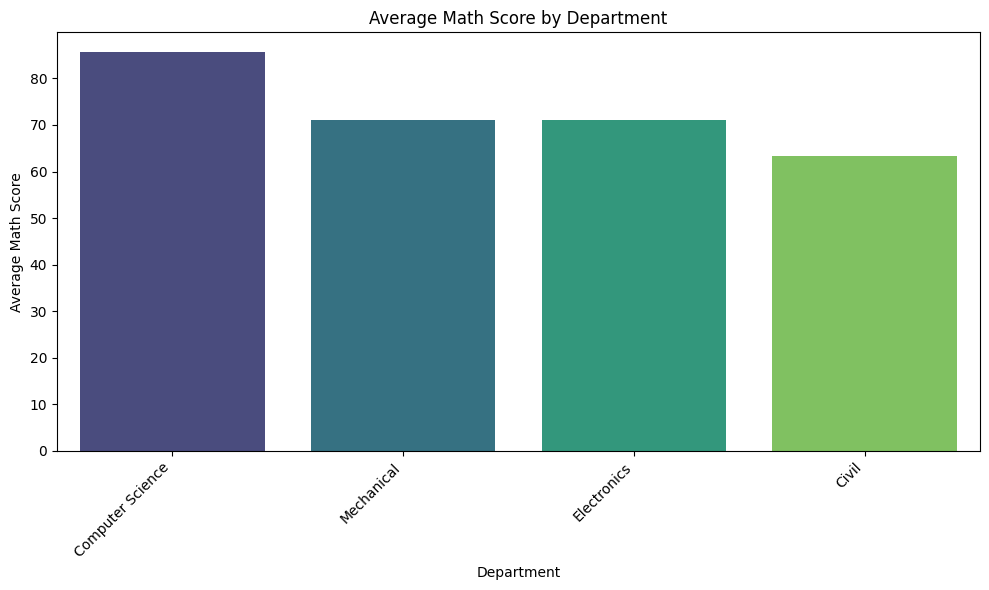

In [159]:
# Step 1: Get data
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM student_performance
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = run_query(chart1_sql, "Chart Data: Average Math Score by Department")
# chart1_data: 'department' and 'avg_math'

# Step 2: Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
# fig: figure, ax: plot area

import seaborn as sns

sns.barplot(x='department', y='avg_math', data=chart1_data, palette='viridis', ax=ax)
ax.set_title('Average Math Score by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
plt.xticks(rotation=45, ha='right') # Rotate x-labels
plt.tight_layout() # Adjust layout
plt.show()


Chart Data: Average Math Score by Department
      department  avg_math
Computer Science     85.62
      Mechanical     71.00
     Electronics     71.00
           Civil     63.40


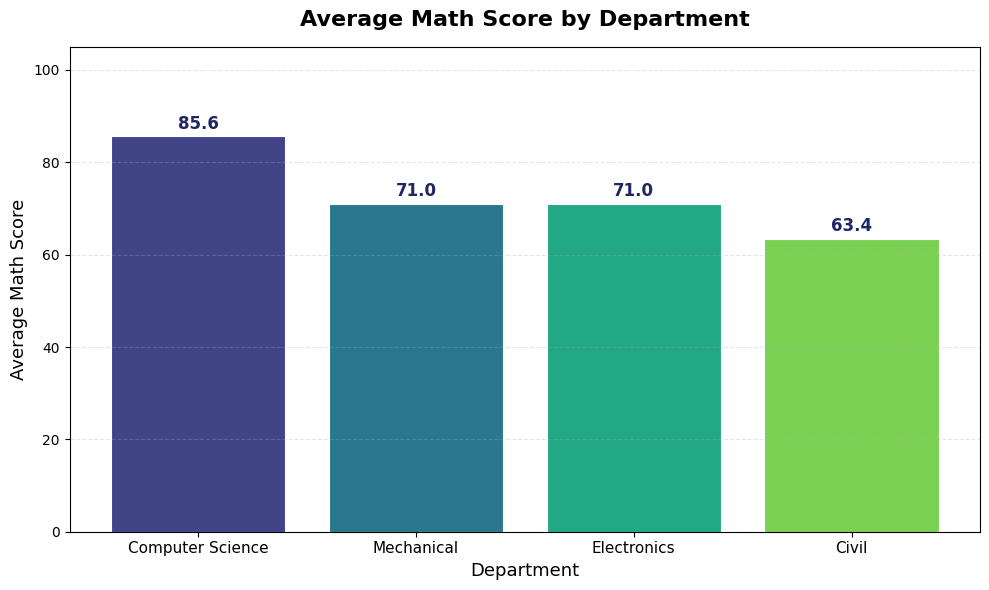

In [160]:
import seaborn as sns

chart1_sql = """
  SELECT department, ROUND(AVG(math_score), 2) AS avg_math
  FROM student_performance
  GROUP BY department
  ORDER BY avg_math DESC
"""

chart1_data = run_query(chart1_sql, "Chart Data: Average Math Score by Department")

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = sns.color_palette('viridis', len(chart1_data))

bars = ax.bar(
  chart1_data['department' ],
  chart1_data['avg_math' ],
  color=bar_colors,
  edgecolor='white',
  linewidth=0.8
)

for bar in bars:
  height = bar.get_height()
  ax.text(
    bar.get_x()+ bar.get_width() / 2, # x-pos: center of bar
    height + 0.8,
    f'{height:.1f}',
    ha='center', va='bottom',
    fontsize=12, fontweight='bold',
    color='#1E2761'
  )

ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105) # y-axis from 0 to 105
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')


plt.tight_layout() # Adjust spacing


plt.show()

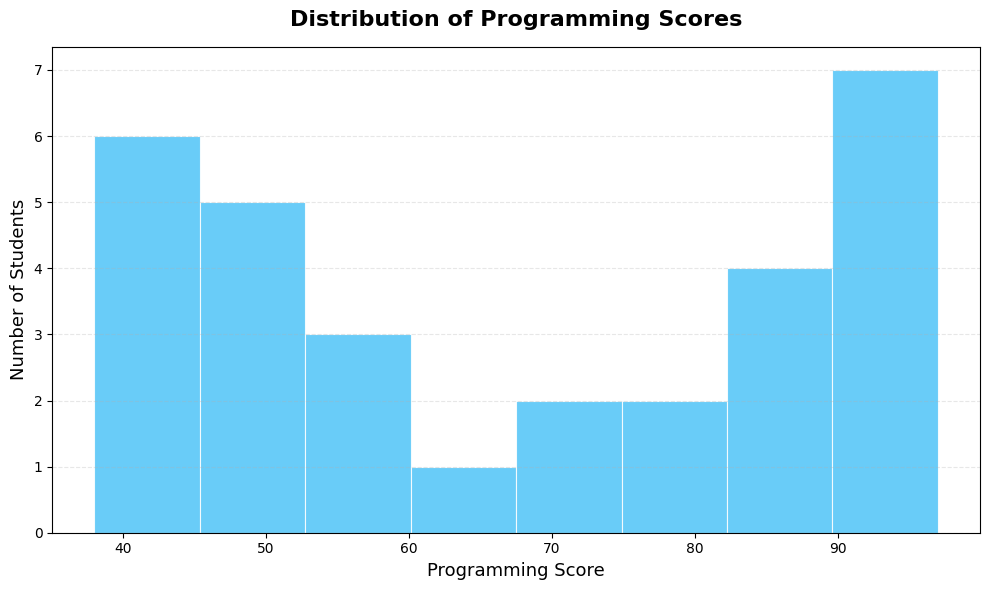

In [161]:
# Get programming scores
prog_scores = df['programming_score'].tolist()

fig, ax = plt.subplots(figsize=(10,6))

n, bins, patches = ax.hist(
  prog_scores,
  bins=8,
  color='#4FC3F7',
  edgecolor='white',
  linewidth=0.8,
  alpha=0.85
)

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()